# Markov-Switching AR Model for Cointegrated Spread

This notebook:
1. Downloads two cointegrated stocks from Yahoo Finance
2. Computes the spread via OLS-estimated β
3. Partitions spread history into **k regimes** by quantile level
4. Estimates a **Markov transition matrix** between regimes
5. Fits a **regime-specific AR(1) process** per the cointegration model:
   $$\varepsilon_t - \phi_i \varepsilon_{t-1} = c_i + \delta_{i,t}, \quad \delta_{i,t} \sim \mathcal{N}(0, \sigma_i^2)$$
6. **Generates** a synthetic spread path by sampling regimes from the Markov chain and drawing innovations from the regime AR


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf

from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.stattools import coint, adfuller
from scipy import stats

OUT_DIR = Path('gendata')
OUT_DIR.mkdir(exist_ok=True)

rng = np.random.default_rng(42)
sns.set_theme(style='whitegrid', palette='tab10')
print(f'All imports OK.  Output folder: {OUT_DIR.resolve()}')

All imports OK.  Output folder: C:\Users\lpset\Desktop\code\Uni\RP\gendata\gendata


## 1  — Configuration

In [2]:
# ── Tickers ──────────────────────────────────────────────────────────────────
TICKER1    = 'MPC'          # leg 1  (P_s1)
TICKER2    = 'PSX'          # leg 2  (P_s2)
START_DATE = '2018-01-01'
END_DATE   = '2024-12-31'

# ── Model ────────────────────────────────────────────────────────────────────
K           = 3      # number of Markov regimes
AR_ORDER    = 1      # AR order per regime  (1 = AR(1) as in the formulas)

# ── Generation ───────────────────────────────────────────────────────────────
N_GENERATE  = 5000    # synthetic steps to generate

# ── Plotting colours ─────────────────────────────────────────────────────────
REGIME_COLORS = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50', '#9C27B0'][:K]

## 2  — Download & cointegration test

Downloaded 1760 daily closes  (2018-01-02 → 2024-12-30)

Engle–Granger cointegration  t=-2.499  p=0.2793
⚠ No strong cointegration — results may be unreliable with these tickers.


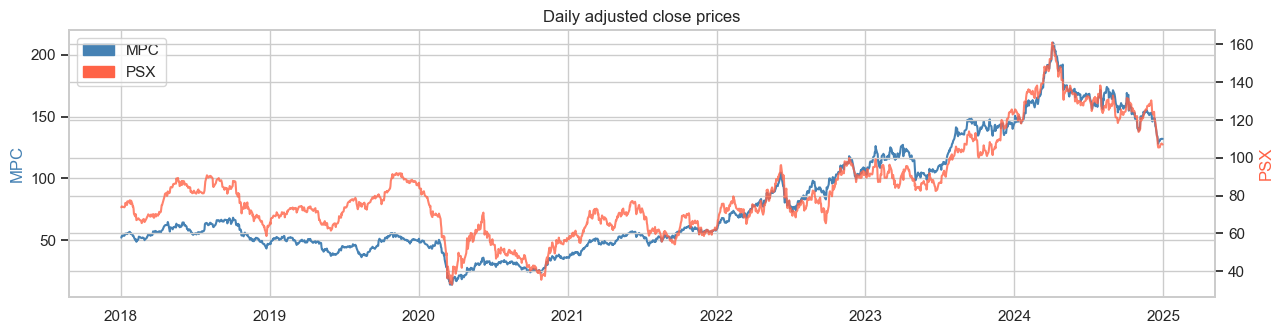

In [3]:
raw = yf.download([TICKER1, TICKER2], start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)['Close']
raw = raw.dropna()
print(f'Downloaded {len(raw)} daily closes  ({raw.index[0].date()} → {raw.index[-1].date()})')

# Engle–Granger cointegration test
coint_t, coint_p, crit = coint(raw[TICKER1], raw[TICKER2])
print(f'\nEngle–Granger cointegration  t={coint_t:.3f}  p={coint_p:.4f}')
if coint_p < 0.05:
    print('✓ Cointegration detected at 5 % significance.')
else:
    print('⚠ No strong cointegration — results may be unreliable with these tickers.')

# Plot prices
fig, ax = plt.subplots(figsize=(13, 3.5))
ax2 = ax.twinx()
ax.plot(raw.index, raw[TICKER1], label=TICKER1, color='steelblue')
ax2.plot(raw.index, raw[TICKER2], label=TICKER2, color='tomato', alpha=.8)
ax.set_title('Daily adjusted close prices')
ax.set_ylabel(TICKER1, color='steelblue')
ax2.set_ylabel(TICKER2, color='tomato')
lines = [mpatches.Patch(color='steelblue', label=TICKER1),
         mpatches.Patch(color='tomato',    label=TICKER2)]
ax.legend(handles=lines, loc='upper left')
plt.tight_layout(); plt.show()

## 3  — Spread estimation

Following the cointegration model:
$$P_{s_1}(t) + \beta P_{s_2}(t) = \varepsilon_t$$

We estimate $\beta$ by OLS regression of $P_{s_1}$ on $P_{s_2}$.

OLS hedge ratio  α=-62.1545  β=1.7213
Spread stats:  mean=222.777  std=86.995
ADF on spread:  stat=-0.882  p=0.7939
⚠ Spread may not be stationary.


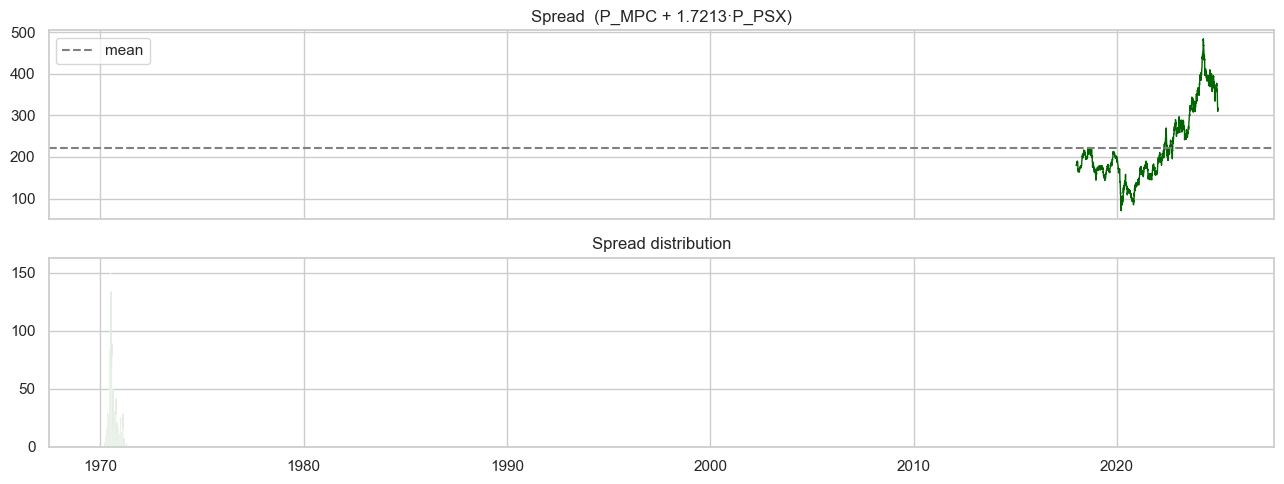

In [4]:
X_ols = add_constant(raw[TICKER2].values)
ols   = OLS(raw[TICKER1].values, X_ols).fit()

alpha_hat = ols.params[0]
beta_hat  = ols.params[1]

# spread = P_s1 + beta * P_s2  (residuals of the cointegrating regression)
spread = pd.Series(
    raw[TICKER1].values + beta_hat * raw[TICKER2].values,
    index=raw.index, name='spread'
)

print(f'OLS hedge ratio  α={alpha_hat:.4f}  β={beta_hat:.4f}')
print(f'Spread stats:  mean={spread.mean():.3f}  std={spread.std():.3f}')

# ADF on the spread
adf_stat, adf_p, *_ = adfuller(spread, autolag='AIC')
print(f'ADF on spread:  stat={adf_stat:.3f}  p={adf_p:.4f}')
if adf_p < 0.05:
    print('✓ Spread is stationary — cointegration confirmed.')
else:
    print('⚠ Spread may not be stationary.')

fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(spread.index, spread, color='darkgreen', lw=1)
axes[0].axhline(spread.mean(), color='gray', ls='--', label='mean')
axes[0].set_title(f'Spread  (P_{TICKER1} + {beta_hat:.4f}·P_{TICKER2})')
axes[0].legend()
axes[1].hist(spread, bins=60, color='darkgreen', alpha=.7, edgecolor='white')
axes[1].set_title('Spread distribution')
plt.tight_layout(); plt.show()

## 4  — Regime assignment (quantile-based)

We split the spread's range into **K equal-probability buckets** (quantiles).  
Regime 0 = lowest spread level, Regime K−1 = highest.

Regime thresholds (spread level):
  Regime 0  [70.512, 172.973)   n=587
  Regime 1  [172.973, 231.717)   n=586
  Regime 2  [231.717, 484.079)   n=587


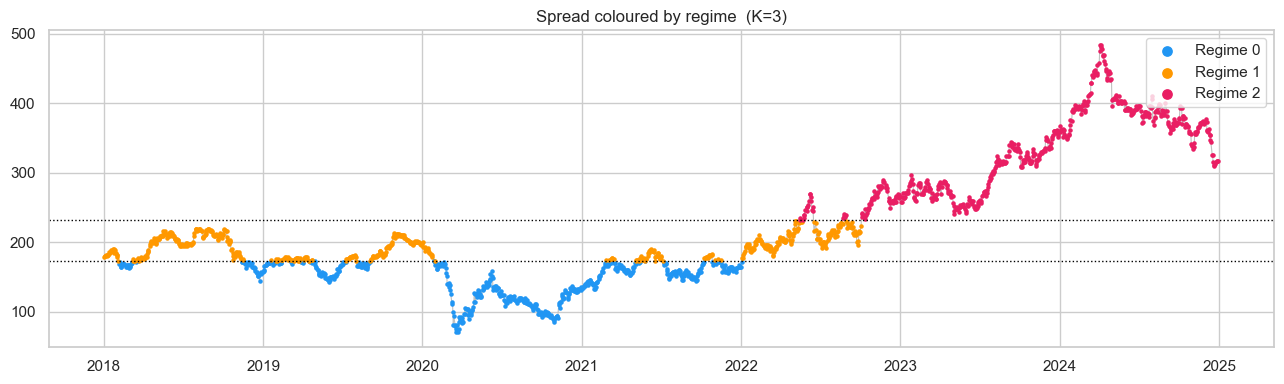

In [5]:
quantile_edges = np.quantile(spread, np.linspace(0, 1, K + 1))
quantile_edges[0]  -= 1e-8   # ensure left-inclusion
quantile_edges[-1] += 1e-8

regimes = pd.Series(
    np.digitize(spread.values, quantile_edges[1:-1]),   # 0 … K-1
    index=spread.index, name='regime'
)

print('Regime thresholds (spread level):')
for k in range(K):
    lo, hi = quantile_edges[k], quantile_edges[k+1]
    cnt = (regimes == k).sum()
    print(f'  Regime {k}  [{lo:.3f}, {hi:.3f})   n={cnt}')

# Visualise regimes on spread
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(spread.index, spread, color='silver', lw=.8, zorder=1)
for k in range(K):
    mask = regimes == k
    ax.scatter(spread.index[mask], spread[mask],
               color=REGIME_COLORS[k], s=5, label=f'Regime {k}', zorder=2)
for edge in quantile_edges[1:-1]:
    ax.axhline(edge, color='black', ls=':', lw=1)
ax.set_title(f'Spread coloured by regime  (K={K})')
ax.legend(markerscale=3, loc='upper right')
plt.tight_layout(); plt.show()

## 5  — Markov transition matrix

Count empirical one-step regime transitions, then row-normalise to get
conditional probabilities $P(s_{t+1}=j \mid s_t=i)$.

Transition probability matrix:
          to 0    to 1    to 2
from 0  0.9557  0.0443  0.0000
from 1  0.0444  0.9488  0.0068
from 2  0.0000  0.0051  0.9949

Stationary distribution: [0.3004 0.2998 0.3998]


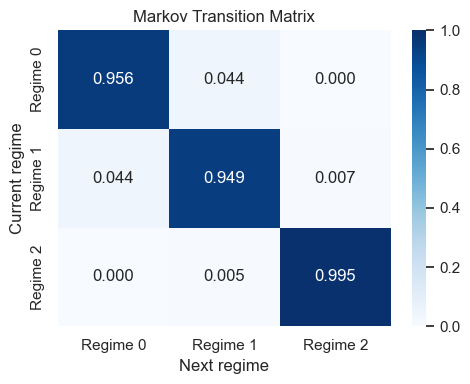

In [6]:
# Count transitions
trans_counts = np.zeros((K, K), dtype=float)
reg_vals = regimes.values
for t in range(1, len(reg_vals)):
    trans_counts[reg_vals[t-1], reg_vals[t]] += 1

# Row-normalise
row_sums = trans_counts.sum(axis=1, keepdims=True)
trans_matrix = trans_counts / row_sums

trans_df = pd.DataFrame(
    trans_matrix,
    index=[f'from {k}' for k in range(K)],
    columns=[f'to {k}' for k in range(K)]
)
print('Transition probability matrix:')
print(trans_df.round(4).to_string())

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(trans_matrix.T)
stat_idx  = np.argmin(np.abs(eigvals - 1.0))
stat_dist = np.real(eigvecs[:, stat_idx])
stat_dist /= stat_dist.sum()
print('\nStationary distribution:', np.round(stat_dist, 4))

# Heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(trans_matrix, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[f'Regime {k}' for k in range(K)],
            yticklabels=[f'Regime {k}' for k in range(K)],
            ax=ax, vmin=0, vmax=1)
ax.set_title('Markov Transition Matrix')
ax.set_ylabel('Current regime'); ax.set_xlabel('Next regime')
plt.tight_layout(); plt.show()

## 6  — Regime-specific AR parameter estimation

For each regime $i$, fit:
$$\varepsilon_t = c_i + \phi_i\, \varepsilon_{t-1} + \delta_{i,t}, \quad \delta_{i,t} \sim \mathcal{N}(0,\sigma_i^2)$$

using OLS on all observations **entering** regime $i$ (i.e. $s_t = i$, regardless of $s_{t-1}$).  
This estimates the within-regime dynamics of the spread.

In [7]:
spread_vals = spread.values
ar_params   = {}       # {regime: {'c': ..., 'phi': [...], 'sigma': ...}}

for k in range(K):
    # Indices t where regime[t] == k  (need t-AR_ORDER to exist)
    idx_k = np.where(reg_vals == k)[0]
    idx_k = idx_k[idx_k >= AR_ORDER]

    y = spread_vals[idx_k]                                        # ε_t
    X = np.column_stack([spread_vals[idx_k - lag]                 # ε_{t-1}, ...
                         for lag in range(1, AR_ORDER + 1)])
    X = add_constant(X, has_constant='add')

    m   = OLS(y, X).fit()
    c_i   = m.params[0]
    phi_i = m.params[1:1 + AR_ORDER]        # array of length AR_ORDER
    resid = m.resid
    sig_i = resid.std(ddof=X.shape[1])

    ar_params[k] = {
        'c':     c_i,
        'phi':   phi_i,
        'sigma': sig_i,
        'r2':    m.rsquared,
        'n':     len(y),
        'resid': resid,
    }

print('Regime AR parameters:')
print(f'{"Regime":>7}  {"n":>6}  {"c":>10}  {"phi(1)":>10}  {"sigma":>10}  {"R²":>6}')
print('-' * 60)
for k, p in ar_params.items():
    phi1 = p['phi'][0] if AR_ORDER >= 1 else float('nan')
    print(f'{k:>7}  {p["n"]:>6}  {p["c"]:>10.4f}  {phi1:>10.4f}'
          f'  {p["sigma"]:>10.4f}  {p["r2"]:>6.4f}')

Regime AR parameters:
 Regime       n           c      phi(1)       sigma      R²
------------------------------------------------------------
      0     587      2.5727      0.9811      3.9975  0.9760
      1     585      9.3318      0.9532      3.5510  0.9482
      2     587      2.9173      0.9918      5.6314  0.9914


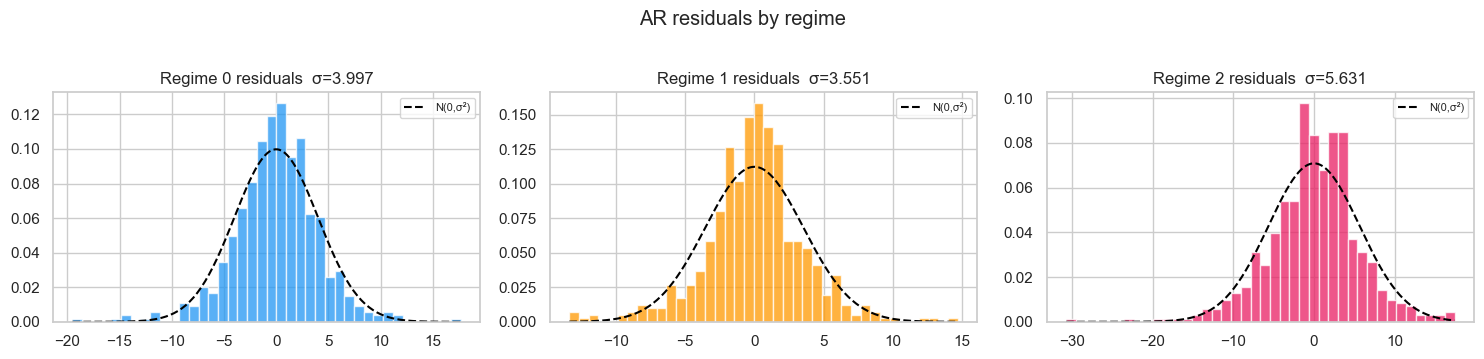

In [8]:
# Residual diagnostics per regime
fig, axes = plt.subplots(1, K, figsize=(5 * K, 3.5))
if K == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    p = ar_params[k]
    ax.hist(p['resid'], bins=40, color=REGIME_COLORS[k], alpha=.75, edgecolor='white',
            density=True)
    xs = np.linspace(p['resid'].min(), p['resid'].max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, 0, p['sigma']), 'k--', lw=1.5, label='N(0,σ²)')
    ax.set_title(f'Regime {k} residuals  σ={p["sigma"]:.3f}')
    ax.legend(fontsize=8)
plt.suptitle('AR residuals by regime', y=1.02)
plt.tight_layout(); plt.show()

## 7  — Synthetic spread generation

At each step:
1. Sample $s_t$ from $P(\cdot \mid s_{t-1})$ (Markov chain)
2. Draw $\delta_{s_t,t} \sim \mathcal{N}(0, \sigma_{s_t}^2)$
3. Compute $\varepsilon_t = c_{s_t} + \phi_{s_t} \varepsilon_{t-1} + \delta_{s_t,t}$

In [9]:
def generate_spread_markov(
    n_steps: int,
    seed_spread: np.ndarray,    # warm-start: last AR_ORDER values
    seed_regime: int,
    trans_mat:   np.ndarray,
    params:      dict,
    ar_order:    int = 1,
    rng          = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns
    -------
    gen_spread  : shape (n_steps,)
    gen_regimes : shape (n_steps,)
    """
    if rng is None:
        rng = np.random.default_rng()

    K = trans_mat.shape[0]
    buffer = list(seed_spread[-ar_order:])   # rolling window of past values

    gen_spread  = np.empty(n_steps)
    gen_regimes = np.empty(n_steps, dtype=int)

    current_regime = seed_regime
    for t in range(n_steps):
        # 1. Transition
        next_regime = rng.choice(K, p=trans_mat[current_regime])

        # 2. AR innovation
        p   = params[next_regime]
        eps = rng.normal(0.0, p['sigma'])

        # 3. AR recursion:  ε_t = c + Σ φ_lag * ε_{t-lag} + δ
        ar_contrib = p['c'] + sum(
            p['phi'][lag] * buffer[-(lag + 1)]
            for lag in range(ar_order)
        )
        new_val = ar_contrib + eps

        gen_spread[t]  = new_val
        gen_regimes[t] = next_regime

        buffer.append(new_val)
        current_regime = next_regime

    return gen_spread, gen_regimes


# Seed with the last AR_ORDER observed spread values
seed_spread  = spread_vals[-AR_ORDER:]
seed_regime  = reg_vals[-1]

gen_spread, gen_regimes = generate_spread_markov(
    n_steps    = N_GENERATE,
    seed_spread= seed_spread,
    seed_regime= seed_regime,
    trans_mat  = trans_matrix,
    params     = ar_params,
    ar_order   = AR_ORDER,
    rng        = rng,
)

print(f'Generated {N_GENERATE} synthetic steps.')
print(f'Spread stats (historical): mean={spread.mean():.3f}  std={spread.std():.3f}')
print(f'Spread stats (generated) : mean={gen_spread.mean():.3f}  std={gen_spread.std():.3f}')

Generated 5000 synthetic steps.
Spread stats (historical): mean=222.777  std=86.995
Spread stats (generated) : mean=239.734  std=67.620


## 8  — Visualise generated spread

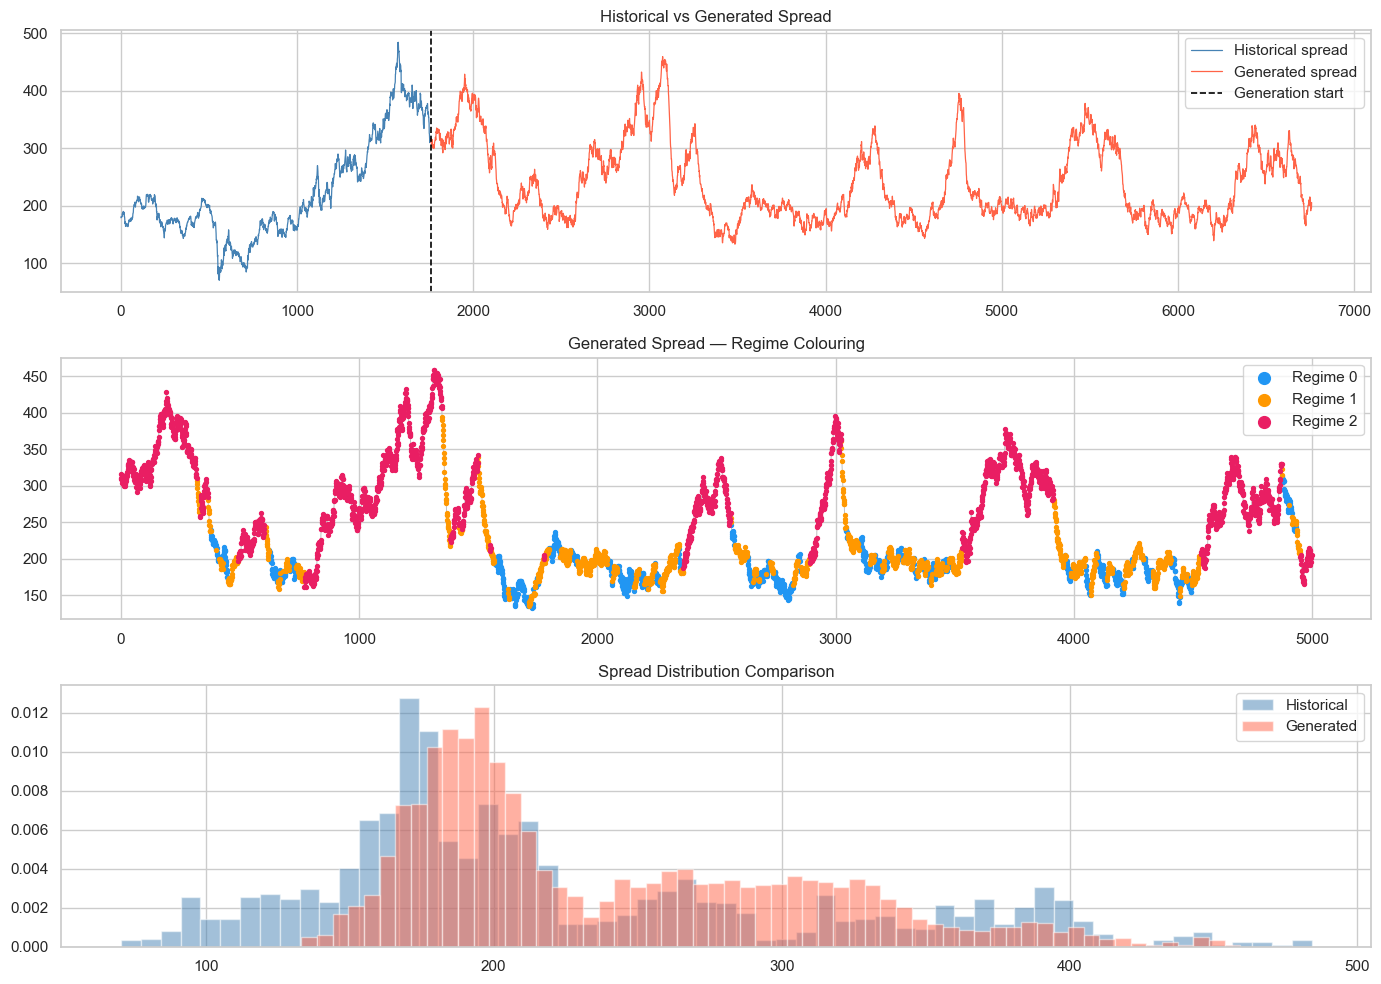

Figure saved.


In [10]:
gen_index = pd.RangeIndex(len(gen_spread))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# ── Panel 1: historical vs generated ─────────────────────────────────────────
ax = axes[0]
ax.plot(np.arange(len(spread)), spread.values,
        label='Historical spread', color='steelblue', lw=.9)
ax.plot(np.arange(len(spread), len(spread) + N_GENERATE), gen_spread,
        label='Generated spread',  color='tomato', lw=.9)
ax.axvline(len(spread), color='black', ls='--', lw=1.2, label='Generation start')
ax.set_title('Historical vs Generated Spread')
ax.legend()

# ── Panel 2: generated spread coloured by regime ──────────────────────────────
ax = axes[1]
ax.plot(gen_index, gen_spread, color='silver', lw=.7, zorder=1)
for k in range(K):
    mask = gen_regimes == k
    ax.scatter(gen_index[mask], gen_spread[mask],
               color=REGIME_COLORS[k], s=8, label=f'Regime {k}', zorder=2)
ax.set_title('Generated Spread — Regime Colouring')
ax.legend(markerscale=3)

# ── Panel 3: distribution comparison ─────────────────────────────────────────
ax = axes[2]
ax.hist(spread.values, bins=60, density=True, alpha=.5,
        color='steelblue', label='Historical', edgecolor='white')
ax.hist(gen_spread,    bins=60, density=True, alpha=.5,
        color='tomato',    label='Generated',  edgecolor='white')
ax.set_title('Spread Distribution Comparison')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'markov_spread_output.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 9  — Regime statistics comparison

Regime occupancy:
          Historical fraction  Generated fraction  Stationary dist
Regime 0               0.3335              0.2438           0.3004
Regime 1               0.3330              0.3048           0.2998
Regime 2               0.3335              0.4514           0.3998


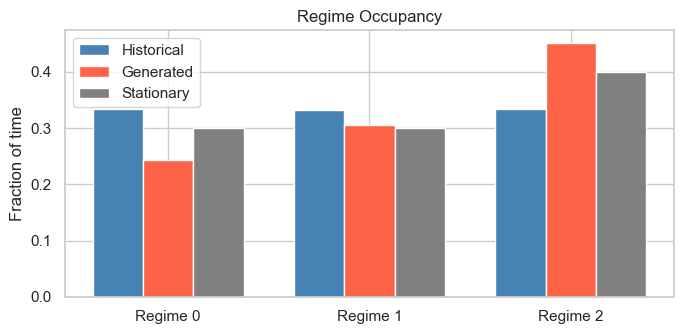

In [11]:
hist_regime_frac = np.array([(reg_vals == k).mean() for k in range(K)])
gen_regime_frac  = np.array([(gen_regimes == k).mean() for k in range(K)])

regime_stats = pd.DataFrame({
    'Historical fraction': hist_regime_frac,
    'Generated fraction':  gen_regime_frac,
    'Stationary dist':     stat_dist,
}, index=[f'Regime {k}' for k in range(K)])
print('Regime occupancy:')
print(regime_stats.round(4).to_string())

x = np.arange(K)
w = 0.25
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - w, hist_regime_frac, w, label='Historical', color='steelblue')
ax.bar(x,     gen_regime_frac,  w, label='Generated',  color='tomato')
ax.bar(x + w, stat_dist,        w, label='Stationary', color='gray')
ax.set_xticks(x); ax.set_xticklabels([f'Regime {k}' for k in range(K)])
ax.set_ylabel('Fraction of time'); ax.set_title('Regime Occupancy')
ax.legend()
plt.tight_layout(); plt.show()

## 10  — Save generated spread

In [12]:
out = pd.DataFrame({
    'step':   np.arange(N_GENERATE),
    'spread': gen_spread,
    'regime': gen_regimes,
})
out.to_csv(OUT_DIR / 'generated_spread.csv', index=False)
print(f'Saved → {OUT_DIR / "generated_spread.csv"}')
out.head(10)

Saved → gendata\generated_spread.csv


,step,spread,regime
0,0,310.725559,2
1,1,316.381759,2
2,2,309.361710,2
3,3,307.951608,2
4,4,303.530194,2
5,5,308.328991,2
6,6,315.056161,2
7,7,310.541077,2
8,8,305.502333,2
9,9,305.623723,2


## 11  — Multiple simulation paths (Monte Carlo)

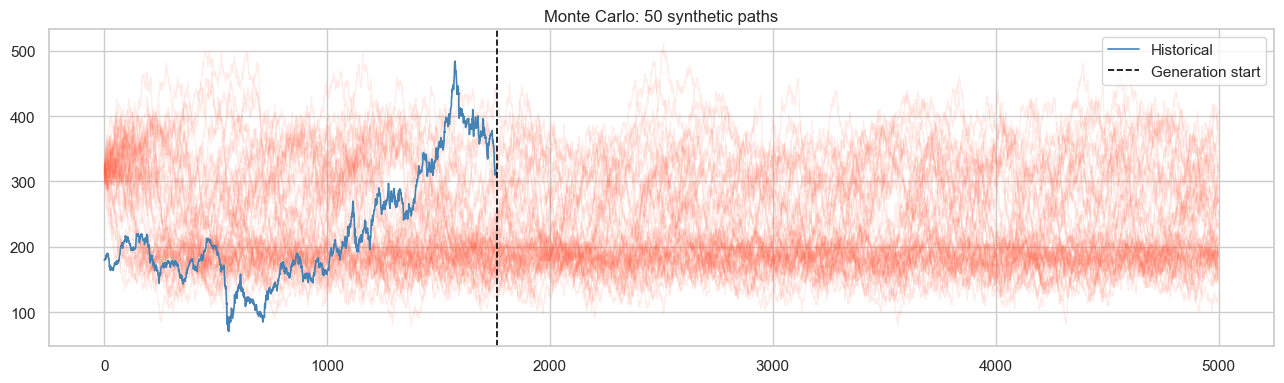

In [13]:
N_PATHS = 50

fig, ax = plt.subplots(figsize=(13, 4))
for i in range(N_PATHS):
    path, _ = generate_spread_markov(
        n_steps    = N_GENERATE,
        seed_spread= seed_spread,
        seed_regime= seed_regime,
        trans_mat  = trans_matrix,
        params     = ar_params,
        ar_order   = AR_ORDER,
        rng        = np.random.default_rng(i),
    )
    ax.plot(path, color='tomato', alpha=0.12, lw=0.8)

ax.plot(spread.values, color='steelblue', lw=1.2, label='Historical')
ax.axvline(len(spread), color='black', ls='--', lw=1.2, label='Generation start')
ax.set_title(f'Monte Carlo: {N_PATHS} synthetic paths')
ax.legend()
plt.tight_layout(); plt.show()